# Variance decomposition — Poisson-GLM vs XGBoost (M29 D23 grid cells)

Reproduces Figure 4's **per-covariate variance decomposition** with **both** XGBoost and a properly-featurized **Poisson GLM (exp link)**, so the two methods can be compared directly, per cell.

**Decomposition (identical recipe for both models).** For the full model (behaviour + coupling cells) we **drop each covariate block** and refit — the drop reduces pR² by exactly that covariate's *unique* contribution:
$$\Delta\text{pR}^2_X = \text{pR}^2(\text{full}) - \text{pR}^2(\text{full}\setminus X)$$
Five covariates: **position · speed · head-direction · LFP · cells** (the 10 grid cells are pooled into one block). Same folds and same Poisson pseudo-R² for both models.

**Setup.** Targets = **all grid cells in M29 D23**; coupling covariate = a **pool of 10 other grid cells**. Behaviour is featurized *for the GLM only* (position→RBF grid, HD→cos/sin, speed & LFP→1-D bumps; coupling cells linear); XGBoost gets Figure-4-raw covariates. Both share `MLencoding.get_all_with_history` (window=`time_bs`, n_filters=5, max_time=1000).

**Figure.** One small scatter per target cell: each point is a covariate, plotted **GLM ΔpR² (x) vs XGBoost ΔpR² (y)** — on the identity line ⇒ the two methods decompose that covariate identically.

> **Self-contained** (loads M29 D23 itself). **Heavy**: drop-one × all GCs × 2 models × CV — start with small `MAX_TARGETS`, then raise / run overnight.

In [1]:
import sys, numpy as np, pandas as pd
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import xgboost as xgbmod
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from spatial_manifolds.mlencoding import MLencoding
from spatial_manifolds.detect_grids import time_bs

WINDOW, NF, MAXT = time_bs, 5, 1000
N_CV        = 10
GLM_ALPHA   = 1e-2                          # L2 for PoissonRegressor (sweep me)
N_RBF, N_RBF1D = 6, 6                       # position = N_RBF^2 bumps; speed & LFP = N_RBF1D 1-D bumps
N_POOL      = 10                            # coupling covariate = 10 other grid cells (pooled block)
MAX_TARGETS = None                             # None = all GC targets (slow!)
BLOCKS = ['position', 'speed', 'hd', 'lfp', 'cells']
LABELS = {'position':'position','speed':'speed','hd':'HD','lfp':'LFP','cells':'cells (pool)'}
CMAP   = {'position':'#f4a261','speed':'#2a9d8f','hd':'#9b5de5','lfp':'#c56fa4','cells':'#c04744'}  # Figure 4 VAR_COLORS + GC_COL
XGB_PARAMS = dict(objective="count:poisson", learning_rate=0.05, min_child_weight=2,
                  n_estimators=580, subsample=0.6, max_depth=5, gamma=0.4,
                  random_state=2925, verbosity=0)
print('params ready · window =', WINDOW, '· folds =', N_CV, '· pool =', N_POOL, 'GCs')

params ready · window = 10 · folds = 10 · pool = 10 GCs


In [2]:
# ── Self-contained session load (M29 D23): kin + all grid-cell IDs ───────────────
import random
import pynapple as nap
from spatial_manifolds.detect_grids import compute_of_tcs, get_theta_trace

SESSION_MOUSE, SESSION_DAY = 29, 23
SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
CC_PATH     = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
GC_REQUIRE_BOTH = False

print(f'Loading M{SESSION_MOUSE} D{SESSION_DAY} ...')
tcs_raw, tcs_time, beh_OF, clusters_OF, ep = compute_of_tcs(
    SESSION_MOUSE, SESSION_DAY, apply_zscore=False, apply_guassian_filter=False,
    fill_nans_from_neighbors=True, source_path=SOURCE_PATH)
last_t = clusters_OF[clusters_OF.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
ep2 = nap.IntervalSet(start=0, end=last_t, time_units='s')
T_ref = len(np.array(tcs_time[next(iter(tcs_time))]))
def _bin(sig):
    a = np.array(sig.bin_average(bin_size=time_bs, time_units='ms', ep=ep2))[:T_ref]
    return pd.Series(a).ffill().bfill().to_numpy()
pos_x, pos_y, speed, hd = _bin(beh_OF['P_x']), _bin(beh_OF['P_y']), _bin(beh_OF['S']), _bin(beh_OF['H'])
T_ref = len(pos_x)
try:
    theta = np.array(get_theta_trace(SESSION_MOUSE, SESSION_DAY, next(iter(tcs_time)), time_bs=50,
                     resample_bs=time_bs, session_type='OF1', source_path=SOURCE_PATH))
    theta = theta[:T_ref] if len(theta) >= T_ref else np.pad(theta, (0, T_ref-len(theta)))
except Exception as e:
    print(f'  theta unavailable ({e}) -> zeros'); theta = np.zeros(T_ref)
kin = np.column_stack([pos_x, pos_y, speed, hd, theta])   # cols FIXED: [pos_x,pos_y,speed,hd,lfp]

cc = pd.read_csv(CC_PATH); cc['mouse']=cc['mouse'].astype(int); cc['day']=cc['day'].astype(int)
_clby = ['both'] if GC_REQUIRE_BOTH else ['both','OF1','OF2']
GC_IDS = sorted({int(c) for c in cc[(cc['mouse']==SESSION_MOUSE)&(cc['day']==SESSION_DAY)&
          (cc['cell_type']=='GC')&(cc['classified_by'].isin(_clby))]['cluster_id'].values if int(c) in tcs_time})
print(f'grid cells in session: {len(GC_IDS)}  | using {MAX_TARGETS or len(GC_IDS)} as targets, pool={N_POOL}')
def yof(tid): return np.asarray(tcs_time[tid])[:T_ref].astype(float)

Loading M29 D23 ...
grid cells in session: 27  | using 27 as targets, pool=10


In [3]:
# ── helpers: design, featurization+blocks, matched-fold CV, drop-one decomposition ─
def poisson_pr2(y, yhat, ynull):
    eps=np.spacing(1); y=np.asarray(y,float); yhat=np.clip(np.asarray(yhat,float),0,None)
    L1=np.sum(y*np.log(eps+yhat)-yhat); L0=np.sum(y*np.log(eps+ynull)-ynull); LS=np.sum(y*np.log(eps+y)-y)
    return 1-(LS-L1)/(LS-L0)

_ml = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False, window=WINDOW, n_filters=NF, max_time=MAXT)
def design(X, y):
    Xd, yd = _ml.get_all_with_history(np.asarray(X,float), np.asarray(y,float)); return np.asarray(Xd), np.asarray(yd).ravel()

def _rbf2d(px, py, n=N_RBF):
    xs=np.linspace(np.nanpercentile(px,2),np.nanpercentile(px,98),n); ys=np.linspace(np.nanpercentile(py,2),np.nanpercentile(py,98),n)
    cx,cy=(g.ravel() for g in np.meshgrid(xs,ys)); cx,cy=np.array(list(cx)),np.array(list(cy)); sig=(xs[1]-xs[0])
    return np.exp(-((px[:,None]-cx[None,:])**2+(py[:,None]-cy[None,:])**2)/(2*sig**2))
def _rbf1d(v, n=N_RBF1D):
    cs=np.linspace(np.nanpercentile(v,2),np.nanpercentile(v,98),n); sig=(cs[1]-cs[0]) if n>1 else 1.0
    return np.exp(-(v[:,None]-cs[None,:])**2/(2*sig**2))

def featurize(X):
    """returns (feat, blocks). X cols = [pos_x,pos_y,speed,hd,lfp, cell1..]; blocks[name]=feat col indices."""
    X=np.asarray(X,float); px,py,sp,h,th=X[:,0],X[:,1],X[:,2],X[:,3],X[:,4]; cells=X[:,5:]
    parts=[('position',_rbf2d(px,py)),('hd',np.column_stack([np.cos(h),np.sin(h)])),('speed',_rbf1d(sp)),('lfp',_rbf1d(th))]
    if cells.shape[1]: parts.append(('cells', cells))
    feat=[]; blocks={}; i=0
    for name,arr in parts: blocks[name]=list(range(i,i+arr.shape[1])); feat.append(arr); i+=arr.shape[1]
    return np.column_stack(feat), blocks
def raw_blocks(X): return {'position':[0,1],'speed':[2],'hd':[3],'lfp':[4],'cells':list(range(5,np.asarray(X).shape[1]))}

def cv_pr2(Xd, yd, model, n_cv=N_CV):
    n=len(yd); ps=[]
    for i in range(n_cv):
        a,b=int(n*i/n_cv),int(n*(i+1)/n_cv); tr=np.r_[0:a,b:n]; ynull=yd[tr].mean()
        if model=='xgb':
            m=xgbmod.XGBRegressor(**XGB_PARAMS).fit(Xd[tr],yd[tr]); ps.append(poisson_pr2(yd[a:b],m.predict(Xd[a:b]),ynull))
        else:
            sc=StandardScaler().fit(Xd[tr]); m=PoissonRegressor(alpha=GLM_ALPHA,max_iter=500).fit(sc.transform(Xd[tr]),yd[tr])
            ps.append(poisson_pr2(yd[a:b],m.predict(sc.transform(Xd[a:b])),ynull))
    return float(np.nanmean(ps))

def decompose(X, y):
    """drop-one ΔpR2 per block for XGBoost(raw) & GLM(basis). Returns full pR2s + per-block ΔpR2."""
    yd = design(X, y)[1]; rb = raw_blocks(X); feat, fb = featurize(X)
    full_xgb = cv_pr2(design(X, y)[0], yd, 'xgb'); full_glm = cv_pr2(design(feat, y)[0], yd, 'glm')
    rows = {}
    for name in BLOCKS:
        keep_r = [c for c in range(X.shape[1])    if c not in rb[name]]
        keep_f = [c for c in range(feat.shape[1]) if c not in fb[name]]
        d_xgb  = cv_pr2(design(X[:, keep_r], y)[0], yd, 'xgb')
        d_glm  = cv_pr2(design(feat[:, keep_f], y)[0], yd, 'glm')
        rows[name] = dict(dpr2_xgb=full_xgb-d_xgb, dpr2_glm=full_glm-d_glm)
    return full_xgb, full_glm, rows
print('helpers ready.')

helpers ready.


## Run the per-covariate decomposition over grid-cell targets

In [4]:
targets = GC_IDS if MAX_TARGETS is None else GC_IDS[:MAX_TARGETS]
rng = random.Random(0)
rec = []
for k, tid in enumerate(targets):
    pool = [c for c in GC_IDS if c != tid]
    cov  = rng.sample(pool, min(N_POOL, len(pool)))
    X = np.column_stack([kin] + [np.asarray(tcs_time[c])[:T_ref] for c in cov])
    fx, fg, rows = decompose(X, yof(tid))
    for name in BLOCKS:
        rec.append(dict(target=tid, block=name, dpr2_xgb=rows[name]['dpr2_xgb'],
                        dpr2_glm=rows[name]['dpr2_glm'], full_xgb=fx, full_glm=fg))
    print(f"  [{k+1}/{len(targets)}] cl{tid}: full xgb={fx:+.3f} glm={fg:+.3f} | "
          + ' '.join(f"{n[:3]} x{rows[n]['dpr2_xgb']:+.3f}/g{rows[n]['dpr2_glm']:+.3f}" for n in BLOCKS))
df = pd.DataFrame(rec); df.head(10)

  [1/27] cl132: full xgb=+0.031 glm=+0.026 | pos x+0.015/g+0.013 spe x+0.001/g+0.002 hd x+0.006/g+0.001 lfp x+0.001/g+0.001 cel x+0.006/g+0.006
  [2/27] cl144: full xgb=+0.090 glm=+0.058 | pos x+0.024/g+0.013 spe x+0.006/g-0.001 hd x+0.022/g+0.008 lfp x+0.003/g-0.000 cel x+0.050/g+0.037
  [3/27] cl160: full xgb=+0.012 glm=+0.009 | pos x+0.003/g+0.001 spe x+0.001/g+0.002 hd x+0.002/g+0.000 lfp x+0.000/g+0.000 cel x+0.010/g+0.004
  [4/27] cl184: full xgb=+0.157 glm=+0.125 | pos x+0.001/g+0.002 spe x+0.009/g+0.005 hd x+0.025/g+0.002 lfp x+0.007/g+0.002 cel x+0.128/g+0.100
  [5/27] cl191: full xgb=+0.099 glm=+0.079 | pos x+0.007/g+0.006 spe x+0.000/g+0.002 hd x+0.021/g+0.005 lfp x+0.006/g+0.008 cel x+0.072/g+0.059
  [6/27] cl194: full xgb=+0.039 glm=+0.030 | pos x+0.003/g+0.003 spe x+0.002/g+0.001 hd x+0.005/g+0.000 lfp x+0.003/g+0.003 cel x+0.025/g+0.021
  [7/27] cl202: full xgb=+0.023 glm=+0.024 | pos x+0.001/g-0.000 spe x+0.002/g+0.001 hd x+0.004/g+0.003 lfp x+0.001/g+0.001 cel x+0.018/

,target,block,dpr2_xgb,dpr2_glm,full_xgb,full_glm
0,132,position,0.015092,0.012751,0.030603,0.026080
1,132,speed,0.001347,0.001573,0.030603,0.026080
2,132,hd,0.005898,0.000875,0.030603,0.026080
3,132,lfp,0.001283,0.001465,0.030603,0.026080
4,132,cells,0.005939,0.006317,0.030603,0.026080
5,144,position,0.024169,0.012695,0.090199,0.058065
6,144,speed,0.006072,-0.000892,0.090199,0.058065
7,144,hd,0.022289,0.008078,0.090199,0.058065
8,144,lfp,0.002994,-0.000385,0.090199,0.058065
9,144,cells,0.050230,0.037217,0.090199,0.058065


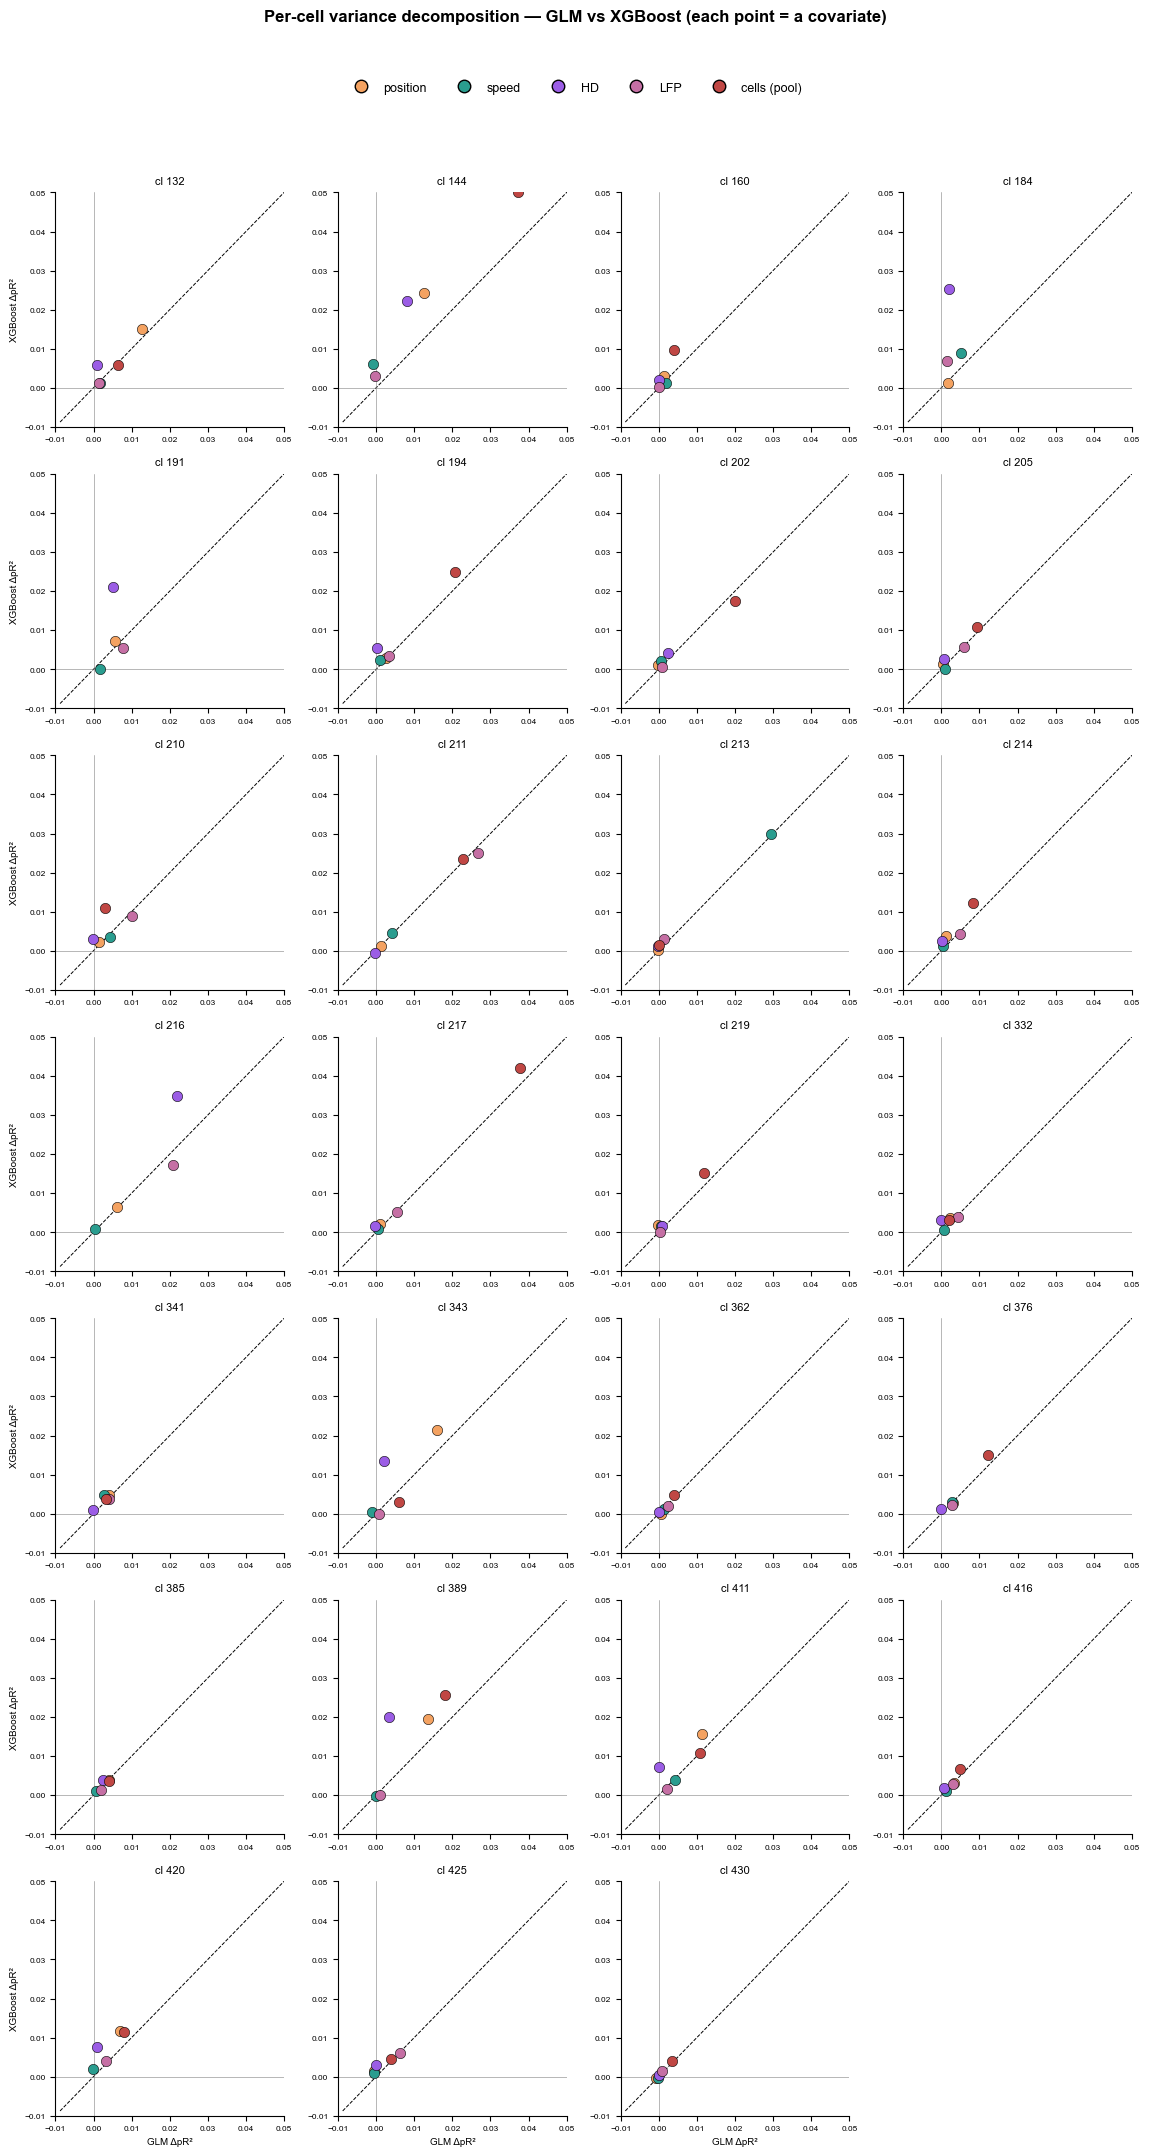

: 

In [ ]:
# One small scatter per target cell: each point = a covariate, GLM ΔpR² (x) vs XGBoost ΔpR² (y)
tids = df.target.unique(); ncell = len(tids)
ncol = min(4, ncell); nrow = int(np.ceil(ncell / ncol))
lo = float(df[['dpr2_glm','dpr2_xgb']].min().min()); hi = float(df[['dpr2_glm','dpr2_xgb']].max().max())
pad = 0.06*(hi-lo+1e-9); lo, hi = lo-pad, hi+pad
fig, axes = plt.subplots(nrow, ncol, figsize=(2.9*ncol, 2.9*nrow), squeeze=False)
for i, tid in enumerate(tids):
    ax = axes[i//ncol][i%ncol]; s = df[df.target==tid]
    ax.plot([lo,hi],[lo,hi],'k--',lw=0.7,zorder=1)
    ax.axhline(0,color='grey',lw=0.4,zorder=1); ax.axvline(0,color='grey',lw=0.4,zorder=1)
    

    for _, r in s.iterrows():
        ax.scatter(r.dpr2_glm, r.dpr2_xgb, s=55, color=CMAP[r.block], edgecolor='k', lw=0.4, zorder=3)
    ax.set_xlim(lo,hi); ax.set_ylim(lo,hi); ax.set_title(f'cl {tid}', fontsize=8)
    ax.set_xlim([-0.01,0.05])    
    ax.set_ylim([-0.01,0.05])
    ax.tick_params(labelsize=6); ax.spines[['top','right']].set_visible(False)
    if i%ncol==0: ax.set_ylabel('XGBoost ΔpR²', fontsize=7)
    if i//ncol==nrow-1: ax.set_xlabel('GLM ΔpR²', fontsize=7)
for j in range(ncell, nrow*ncol): axes[j//ncol][j%ncol].set_visible(False)
handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=CMAP[b],markeredgecolor='k',markersize=9,label=LABELS[b]) for b in BLOCKS]
fig.legend(handles=handles, loc='upper center', ncol=5, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Per-cell variance decomposition — GLM vs XGBoost (each point = a covariate)', y=1.06, fontweight='bold')
plt.tight_layout(); plt.savefig('decomp_percell.pdf', bbox_inches='tight'); plt.show()

## Reading it
Each subplot is one grid-cell target; each point is a covariate's **unique ΔpR²**. On the identity line ⇒ the GLM (exp link) and XGBoost assign that covariate the same variance. A point above the line = XGBoost extracts more than the GLM (nonlinear tuning beyond the basis — raise `N_RBF` before concluding it's real); below = the GLM edges it (usually noise / over-regularized XGBoost).

Drop-one gives *unique* (semipartial) variance, so position and grid cells (collinear, both spatial) each look smaller than their standalone contribution — the shared spatial variance isn't double-counted. Sweep `GLM_ALPHA` / `N_RBF`; set `MAX_TARGETS=None` for all grid cells (heavy).